Ex. 1: Uma rede de supermercados deseja classificar clientes 
em grupos de consumo com base nos seguintes atributos:<br />
– Renda_Mensal (em R$)<br />
– Gasto_Mensal (em R$ no supermercado)<br />
– Classe (categoria do cliente: 1 = baixo consumo, 2 = médio 
consumo, 3 = alto consumo)

a) O KNN conseguiu separar bem os clientes em grupos de 
consumo (baixo, médio e alto)?<br />
b) Há casos em que clientes com renda alta, mas gasto 
baixo, podem ser classificados incorretamente? O que 
isso indica sobre a estratégia de segmentação?<br />
c) Como a escolha do valor de k influencia na fronteira 
entre os grupos?

Amostra das características (X_train):
[[2000.  500.]
 [2500.  700.]
 [3000.  800.]
 [3200. 1000.]
 [3500. 1200.]]

Amostra dos rótulos (y_train):
[1 1 1 2 2]


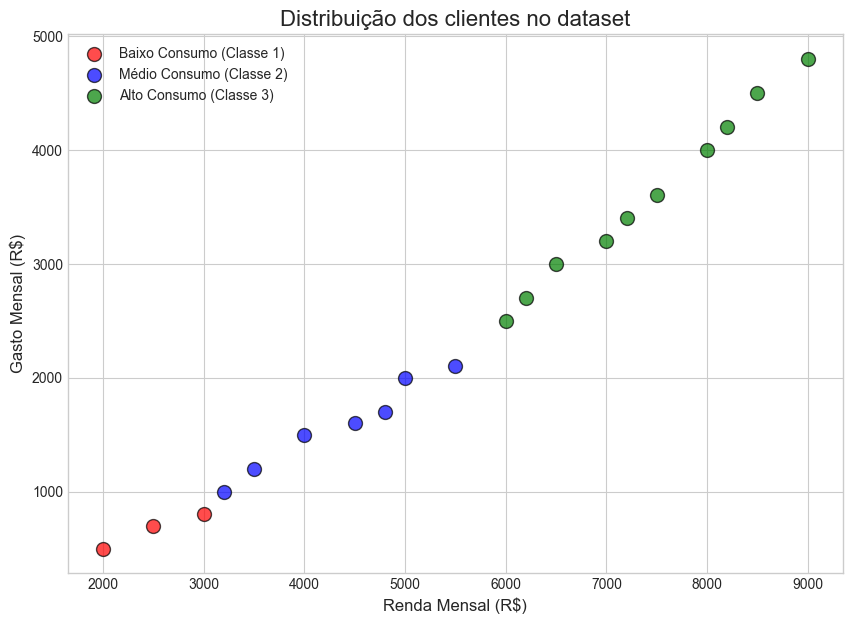

In [24]:
import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

dataset = np.loadtxt("knn_dataset_exercicio_1.txt", delimiter='|', skiprows=2, usecols=(1, 2, 3))

X_train = dataset[:, :2]
y_train = dataset[:, 2].astype(int)

print("Amostra das características (X_train):")
print(X_train[:5])
print("\nAmostra dos rótulos (y_train):")
print(y_train[:5])

plt.style.use('seaborn-v0_8-whitegrid')
flg, ax = plt.subplots(figsize=(10,7))

# Plota os pontos Baixo Consumo (Classe 1)
ax.scatter(X_train[y_train == 1, 0], X_train[y_train == 1, 1],
           c='red', s=100, edgecolors='k', alpha=0.7, label='Baixo Consumo (Classe 1)')

# Plota os pontos Médio Consumo (Classe 2)
ax.scatter(X_train[y_train == 2, 0], X_train[y_train == 2, 1],
           c='blue', s=100, edgecolors='k', alpha=0.7, label='Médio Consumo (Classe 2)')

# Plota os pontos Alto Consumo (Classe 3)
ax.scatter(X_train[y_train == 3, 0], X_train[y_train == 3, 1],
           c='green', s=100, edgecolors='k', alpha=0.7, label='Alto Consumo (Classe 3)')

ax.set_title('Distribuição dos clientes no dataset', fontsize=16)
ax.set_xlabel('Renda Mensal (R$)', fontsize=12)
ax.set_ylabel('Gasto Mensal (R$)', fontsize=12)
ax.legend()
plt.show()

In [ ]:
def calcular_distancia_euclidiana(ponto1, ponto2):
    """Calcula a distância euclidiana entre dois pontos."""
    return np.sqrt(np.sum((ponto1 - ponto2)**2))

def encontrar_vizinhos(X_train, y_train, ponto_teste, k):
    """Encontra os k vizinhos mais próximos de um ponto de teste."""
    distancias = []
    for i, ponto_treino in enumerate(X_train):
        dist = calcular_distancia_euclidiana(ponto_treino, ponto_teste)
        distancias.append((dist, y_train[i]))

    # Ordena a lista de distâncias em ordem crescente
    distancias.sort(key=lambda x: x[0])

    # Retorna os k vizinhos mais próximos (seus rótulos)
    vizinhos = [distancia[1] for distancia in distancias[:k]]
    return vizinhos

def prever_classificacao(vizinhos):
    """Faz a previsão com base no voto majoritário dos vizinhos."""
    # Conta a ocorrência de cada classe nos vizinhos
    contagem_votos = Counter(vizinhos)
    # Retorna a classe mais comum
    previsao = contagem_votos.most_common(1)[0][0]
    return previsao

Ex. 2: Uma empresa de tecnologia deseja classificar seus 
funcionários em níveis de desempenho com base em:<br />
–Horas_Treinamento (quantidade de horas de treinamento por 
mês)<br />
–Projetos_Entregues (quantidade de projetos entregues no 
trimestre)<br />
–Nivel (classificação do desempenho: 1 = baixo, 2 = médio, 3 = 
alto)<br />

a) O KNN separou corretamente os funcionários de baixo, médio 
e alto desempenho com base nos atributos de treinamento e 
projetos?<br />
b) Funcionários com muitas horas de treinamento, mas poucos 
projetos, poderiam ser classificados incorretamente? O que 
isso sugere sobre a escolha dos atributos?<br />
c) Se um novo funcionário tivesse 20 horas de treinamento e 3 
projetos entregues, em qual categoria o KNN provavelmente 
o colocaria?